# Midterm: Export Strategy
## Anthony Costanzo
## Friday, March 6th

#### Executive Summary

#### Background Performance

In [ ]:
# Install pandas numpy matplotlib
%pip install pandas numpy matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Problem 3: 
### Conduct growth accounting (1980 - 2019) using the production function with human capital from Assignment/PSet 2 and produce (1) one productivity trajectory graph, and (2) one short interpretation.
#### Variables Required:
- Real GDP (rgdp or cgdpo)
- Capital Stock (rkna or cn)
- Population (pop)
- Human Capital Index (hc)
- Year (year)
#### Formulas Required
- Production function with human capital
- Standard Capital Share (alpha = 0.33)
- A = Y/K^0.33(hL)^0.67
#### Variables to Construct
- Per worker variables: GDP per worker (y = Y/L) and Capital per worker (k = K/L)
- Log TFP

In [ ]:
# Import Packages and Load Data
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [5]:
# Loading Data
pwt = pd.read_csv("/Users/workspace/Desktop/Spring 2026/Code/GLBL 5010/economics-for-global-affairs/midterm/final-pwt.csv")

In [12]:
# Set capital share parameter: A = Y / K^0.33 * (hL)^0.67
alpha = 0.33

def add_series(df, start_year=1980):
    df = df[df["year"] >= start_year].copy()             
    df["y"] = df["rgdpo"] / df["pop"]                    # output per capita (Y/L)
    df["k"] = df["cn"] / df["pop"]                       # capital per capita (K/L)
    df["A"] = df["y"] / (df["k"] ** alpha * df["hc"] ** (1 - alpha))  # TFP residual from production function
    df["lny"] = np.log(df["y"])                          # log output per capita
    df["lnk"] = np.log(df["k"])                          # log capital per capita
    df["lnA"] = np.log(df["A"])                          # log TFP
    return df

In [19]:
# Filter to South Korea and Taiwan and compute time series
pwt_kr = add_series(pwt[pwt["countrycode"] == "KOR"])    # primary country — subset to Korea rows and run add_series
pwt_tw = add_series(pwt[pwt["countrycode"] == "TWN"])    # comparator — same as above but for Taiwan


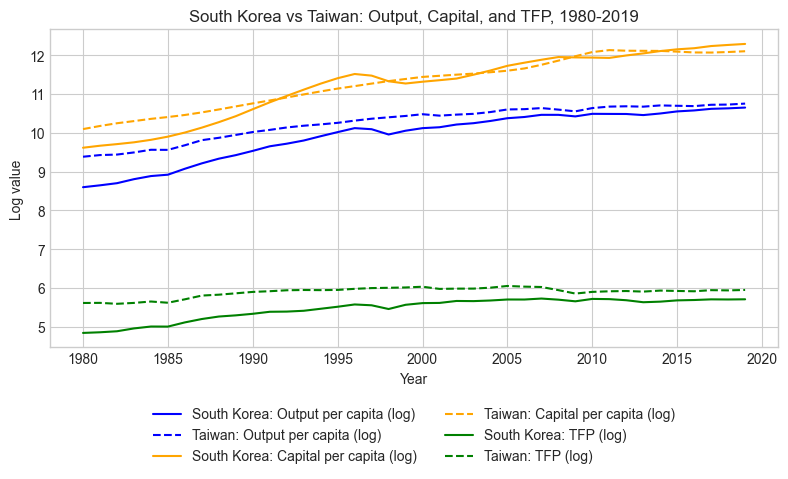

In [21]:
# Variable names, legend labels, and colors
variables = {"lny": "Output per capita (log)", "lnk": "Capital per capita (log)", "lnA": "TFP (log)"} 
colors    = {"lny": "blue", "lnk": "orange", "lnA": "green"}

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(8, 5))

# Plot each variable for both countries — South Korea solid, Taiwan dashed
for var, label in variables.items():
    plt.plot(pwt_kr["year"], pwt_kr[var], color=colors[var], label=f"South Korea: {label}")
    plt.plot(pwt_tw["year"], pwt_tw[var], color=colors[var], linestyle="--", label=f"Taiwan: {label}")

plt.xlabel("Year")
plt.ylabel("Log value")
plt.title("South Korea vs Taiwan: Output, Capital, and TFP, 1980-2019")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

South Korea's strong economic growth from 1980 to 2019 was driven primarily by capital accumulation rather than productivity gains, suggesting that future growth will require a shift toward policies that boost TFP. Over the four-decade period, Korea's capital per capita grew substantially, rising from roughly 10 to over 12 log points, while total factor productivity remained nearly flat throughout — a pattern that persisted even after Korea democratized in 1987, suggesting that political liberalization alone was insufficient to shift the economy toward TFP-driven growth. Taiwan's trajectory tells a similar story: despite undergoing its own democratic transition the same year, Taiwan's TFP also stagnated, though its comparatively slower capital deepening meant Korea was able to close the output-per-capita gap with Taiwan entirely by 2019. Together, both economies appear to have exhausted the easy gains from adding capital and labor — consistent with Krugman's argument about capital accumulation driving Soviet-style growth — pointing to the need for policies that directly target allocative efficiency, R&D, and innovation.

## Problem 4a
### Conduct export structure analysis (2000 vs 2022) and compute Revealed Comparative Advantage (RCA). Produce (1) one export/comparative advantage graph, and (2) one short interpretation.
#### Dataset required:
- indflow = pd.read_csv("/Users/workspace/Desktop/Spring 2026/Code/GLBL 5010/economics-for-global-affairs/midterm/final-industryflows.csv")
#### Variables Required:
- Exporter (iso_o)
- Industry code (hs2)
- Year (year)
- Country exports (value)
- World Exports (value_wd)
#### Formulas Required:
- Country total exports
- World total exports
- Country explort share in sector
- World export share in sector
- RCA (Balassa Index[?])
#### Variables to Construct
- Country total exports (by year)
- World total exports (by year)
- Sectoral export share (Taiwan)
- Sectoral world share 
- RCA (by sector, for 2000 and 2022)
- Change in RCA (2022 - 2000)

In [36]:
# Load industry flows and filter to South Korea, years 2000 and 2022
industryflows = pd.read_csv("/Users/workspace/Desktop/Spring 2026/Code/GLBL 5010/economics-for-global-affairs/midterm/final-industryflows.csv")
kor = industryflows[(industryflows["iso_o"] == "KOR") & (industryflows["year"].isin([2000, 2021]))].copy()

In [37]:
# Compute RCA for each year independently, then stack
frames = []
for year, group in kor.groupby("year"):
    group = group[group["value"] > 0].copy()               # drop sectors Korea doesn't export
    group["value_tot"]    = group["value"].sum()            # total Korean exports that year
    group["value_wd_tot"] = group["value_wd"].sum()         # total world exports that year
    group["sh_hs2"]       = group["value"] / group["value_wd"]          # Korea's sector share of world exports
    group["sh_wd"]        = group["value_tot"] / group["value_wd_tot"]  # Korea's overall world export share
    group["rca"]          = group["sh_hs2"] / group["sh_wd"]            # Balassa RCA index
    frames.append(group)
kor = pd.concat(frames)

# Pivot to get 2000 and 2021 RCA side by side, then compute change
rca = kor.pivot(index="hs2", columns="year", values="rca").reset_index()
rca.columns.name = None                                                  # clear column axis name
rca = rca.rename(columns={2000: "rca_2000", 2021: "rca_2021"})          # rename by value, not position
rca["rca_change"] = rca["rca_2021"] - rca["rca_2000"]                   # change in RCA 2000-2021

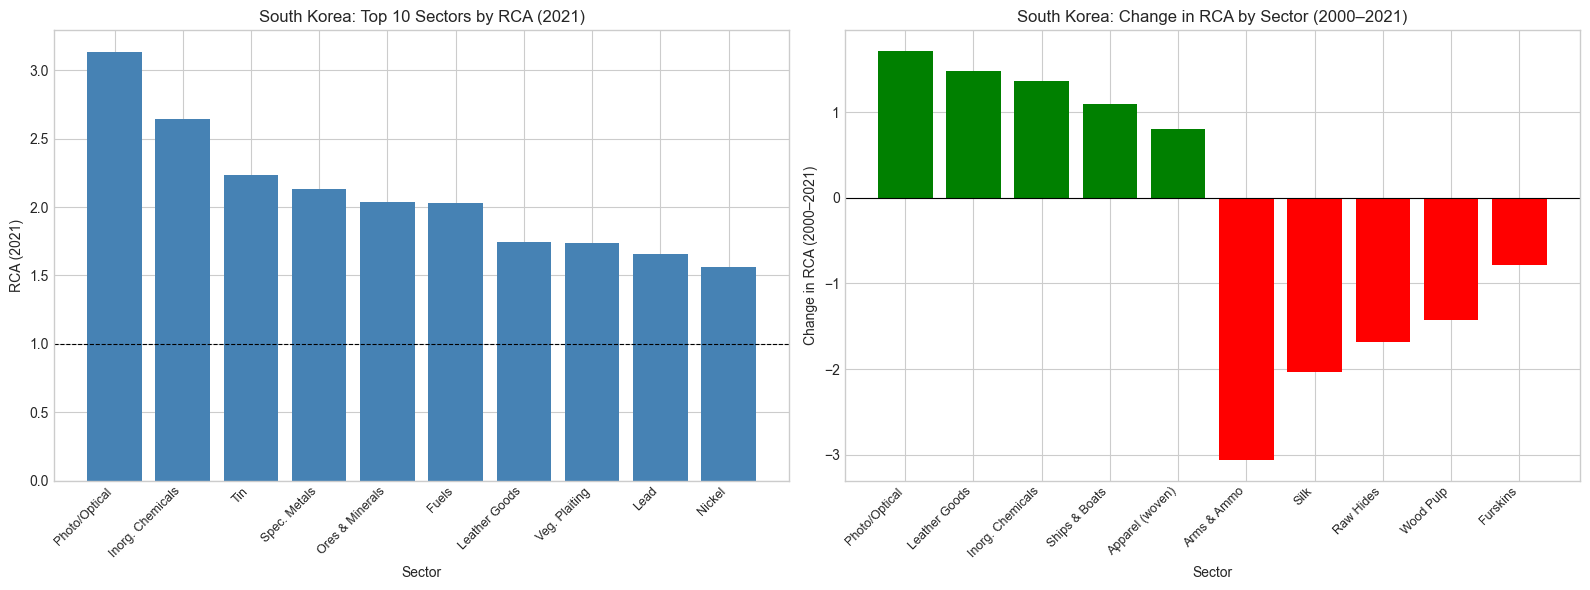

In [39]:
# HS2 code to short sector name mapping (covering all sectors appearing in Korea's top/change charts)
hs2_names = {
    14: "Veg. Plaiting", 26: "Ores & Minerals", 27: "Fuels",
    28: "Inorg. Chemicals", 29: "Org. Chemicals", 37: "Photo/Optical",
    38: "Misc. Chemicals", 39: "Plastics", 40: "Rubber",
    41: "Raw Hides", 42: "Leather Goods", 43: "Furskins",
    47: "Wood Pulp", 50: "Silk", 62: "Apparel (woven)",
    72: "Iron & Steel", 73: "Steel Articles", 75: "Nickel",
    78: "Lead", 80: "Tin", 81: "Spec. Metals",
    84: "Machinery", 85: "Electronics", 87: "Vehicles",
    89: "Ships & Boats", 90: "Precision Instr.", 93: "Arms & Ammo",
}

# Top 10 by RCA level in 2021; top 5 gainers and bottom 5 losers by change
top10 = rca.sort_values("rca_2021", ascending=False).head(10)
sel   = pd.concat([rca.sort_values("rca_change", ascending=False).head(5),
                   rca.sort_values("rca_change").head(5)]).drop_duplicates(subset="hs2")

# Map HS2 codes to readable names for both subsets
top10_labels = top10["hs2"].map(lambda x: hs2_names.get(x, f"HS{x}"))
sel_labels   = sel["hs2"].map(lambda x: hs2_names.get(x, f"HS{x}"))

# Color bars green/red based on direction of RCA change
sel_colors = ["green" if v > 0 else "red" for v in sel["rca_change"]]

plt.style.use("seaborn-v0_8-whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: top 10 sectors by RCA level
ax1.bar(range(len(top10)), top10["rca_2021"], color="steelblue")
ax1.set_xticks(range(len(top10)))
ax1.set_xticklabels(top10_labels, rotation=45, ha="right", fontsize=9)
ax1.axhline(1, color="black", linewidth=0.8, linestyle="--")            # RCA = 1 threshold
ax1.set_xlabel("Sector")
ax1.set_ylabel("RCA (2021)")
ax1.set_title("South Korea: Top 10 Sectors by RCA (2021)")

# Right panel: biggest gainers and losers, colored by direction
ax2.bar(range(len(sel)), sel["rca_change"], color=sel_colors)
ax2.set_xticks(range(len(sel)))
ax2.set_xticklabels(sel_labels, rotation=45, ha="right", fontsize=9)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Sector")
ax2.set_ylabel("Change in RCA (2000–2021)")
ax2.set_title("South Korea: Change in RCA by Sector (2000–2021)")

plt.tight_layout()
plt.show()



South Korea's export structure reveals a paradox: its world-famous industries do not reflect its deepest comparative advantages. In 2021, Korea's strongest specialization lies in Photo/Optical instruments (HS 90) and Inorganic Chemicals (HS 28), with RCA indices above 2.5, suggesting Korea's competitive edge is concentrated in precision manufacturing and industrial chemistry rather than consumer electronics broadly. This matters for policy: sectors where the entire world is investing heavily — Electronics (HS 85) and Vehicles (HS 87) — may offer lower marginal returns to additional government support than niche high-precision sectors where Korea already punches above its weight.

Between 2000 and 2021, Korea's comparative advantage shifted decisively away from labor-intensive and legacy industries. The largest RCA declines occurred in Arms & Ammunition (HS 93), Silk (HS 50), and Raw Hides (HS 41), consistent with cost-driven offshoring or deliberate industrial de-emphasis. Meanwhile, Korea deepened its advantage in Photo/Optical equipment (HS 90), Ships & Boats (HS 89), and Inorganic Chemicals (HS 28), reflecting a successful but incomplete industrial upgrade toward knowledge-intensive manufacturing. Policy funds should reinforce this trajectory — targeting the precision optics and specialty chemicals ecosystems — rather than subsidizing mature sectors where comparative advantage is eroding.

## Problem 4b
### Estimate gravity model (latest year) to evaluate WTO effect and simulate WTO collapse counterfactual.
#### Dataset required: 
- indflow = pd.read_csv("/Users/workspace/Desktop/Spring 2026/Code/GLBL 5010/economics-for-global-affairs/midterm/final-gravity.csv")
#### Variables Required:
- Export value (value)
- Origin country (iso_o)
- Destination country (iso_d)
- Year (year)
- Distance (distw)
- Destination GDP (gdp_d)
- Shared border (contig)
- Common language (comlang_ethno)
- Common legal system (comleg_posttrans)
- Regional trade agreement (rta)
- WTO membership indicator (wto_d)
#### Formulas Required:
- Log trade (to retain zero flows)
- Log distance
- Log market size
- Gravity specification
#### Counterfactual:
- Predicted export change if WTO collapses (set WTO_d = 0 for all partners and compare predicted values)
#### Vars to construct:
- lvalue
- ldist
- Predicted trade (yhat)
- Counterfactual predicted trade (WTO_d = 0)
